In [2]:
%load_ext autoreload
%autoreload 2

from collections import OrderedDict
from qiskit_metal import designs
from qiskit_metal import MetalGUI, Dict
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors

from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven #bonding
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround


from SQDMetal.Utilities.QUtilities import QUtilities
import matplotlib.pyplot as plt
import numpy as np
from qiskit_metal.toolbox_python.attr_dict import Dict

from toolkit.components.qubit.circle_transmon import CircTransmon
from toolkit.tools.sim.sim_subdesign import build_subdesign

from scipy.constants import c, e, hbar
from scipy.constants import physical_constants as pc
# %matplotlib inline

In [1]:
res_len_lambda_2 = lambda eff, f: c/(2*np.sqrt(eff)*f)*1e3 # in mm
res_len_lambda_4 = lambda eff, f: c/(4*np.sqrt(eff)*f)*1e3 # in mm

In [3]:
# design = designs.DesignPlanar({}, overwrite_enabled=True)

design = designs.DesignPlanar()
design.chips.main.material = 'silicon'

design.variables['cpw_width'] = '20um' #S from reference 2
design.variables['cpw_gap'] = '11um' #W from reference 2
design._chips['main']['size']['size_x'] = '5mm'
design._chips['main']['size']['size_y'] = '5mm'
design._chips['main']['size']['size_z'] = '-600um' #Our wafer thicknes is 525 um+/-10
design.chips.main.size.center_x = '1.25mm'
design.chips.main.size.center_y = '2.5mm'

# If you disable the next line with "overwrite_enabled", then you will need to
# delete a component [<component>.delete()] before recreating it.
design.overwrite_enabled = True

In [4]:
# gui = MetalGUI(design)

In [4]:
options = Dict(
        # Position and orientation
        pos_x='1.8mm', pos_y='1.6mm', orientation=0, chip='main',
        cpw_width=design.variables['cpw_width'], cpw_gap=design.variables['cpw_gap'],

        # Pads (capacitor)
        pad_radius = '120um',
        pad_gap = '10um',

        # jj (mesoscopic: 0 or small junction: 1)
        jj_options=Dict(
            jj_width='5um',
            L_j = '40.7885nH',
            C_j = '0.72fF',
            export_mask = False,    # if True, draw a rectangle where the constriction will be made. If false, we keep a gap of jj_sim_gap in which we insert a jj element to make the simulation
            gds_cell_jj = 'gds_cell_jj',
            jj_sim_gap = '8um', # if we need a small junction, we can increase this gap
            ),
        
        # Coupled claws (2 claws allowed   )
        claw_a_options= Dict(
            make_claw=True,
            connector_location='90',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='200um',
            ground_spacing='10um',
            connector_length='70um',
            ),
        claw_b_options=Dict(
            make_claw=False,
            connector_location='0',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='100um',
            ground_spacing='10um',
            connector_length='50um',
            ),

        # Charge line
        charge_line=Dict(
            make_charge_line=True,
            location = '180', # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm. Must be different from claw_a and claw_b if they exist
            pad_radius='40um',
            pad_gap='40um', # gap between the pad and qubit
            ground_spacing='15um', # distance from the charge line to the ground
            line_length='100um',
            )
        )

# Create a fluxonium qubit with the Manucharyan design
qubit_1 = CircTransmon(design, 'Q1', options=options)


# gui.rebuild()
# gui.autoscale()

In [5]:
x1 = '0.25mm'
y1 = '3.2mm'

ops_1 = Dict(chip='main', pos_x=x1, pos_y=y1, orientation='360', lead_length='10um', 
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = ops_1)

# Driven Launchpad 2

x2 = '3mm'
y2 = '3.2mm'
ops_2 = Dict(chip='main', pos_x=x2, pos_y=y2, orientation='180', lead_length='10um',
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )
LP2 = LaunchpadWirebondDriven(design, 'LP2', options = ops_2)


# Rebuild the GUI
# gui.rebuild()
# gui.autoscale()

## Conecto LP1 con el extremo izquierdo del capacitor
opt_line = Dict(chip='main', trace_width =design.variables['cpw_width'] ,
        trace_gap =design.variables['cpw_gap'] , fillet='0um', hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LP1', pin='tie'),
                        end_pin=Dict(component='LP2', pin='tie')
                        )
               )

linea_1 = RoutePathfinder(design, 'linea_1', options = opt_line )

# Rebuild the GUI
# gui.rebuild()
# gui.autoscale() 


In [6]:
# charge lumped port
ops_charge_line = Dict(chip='main', pos_x='0.5mm', pos_y='1.6mm', orientation='0', lead_length='10um',
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )

LPC = LaunchpadWirebondDriven(design, 'LPC', options = ops_charge_line)

# Rebuild the GUI
# gui.rebuild()
# gui.autoscale()


In [7]:
# Connect LPC with charge_line pad
# anchors_points = [(0.7, 2), (0.7, 2.5), (0.8, 2.5), (1, 1.6)]
# anchors_dict = OrderedDict({i: point for i, point in enumerate(anchors_points)})

opt_line_charge = Dict(chip='main', trace_width =design.variables['cpw_width'],
        trace_gap = design.variables['cpw_gap'], hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LPC', pin='tie'),
                        end_pin=Dict(component='Q1', pin='charge_line')
                        )
                )

con_charge_line = RoutePathfinder(design, 'con_charge_line', options = opt_line_charge )
# gui.rebuild()
# gui.autoscale()

In [8]:
## Estimation for the resonator length
eff=(11.9+1)/2 ## Si and Air
f=7e9  # Resonator frequency in Hz

stg1 = ShortToGround(design, 'stg1', options=Dict(chip='main', pos_x='1mm',  pos_y='2.3mm', orientation='180'))

In [9]:
jogs = OrderedDict()
jogs[0] = ["L", '400um']
jogs[1] = ["L", '100um']
# jogs[1] = ["L", '300um']
# jogs[2] = ["R", '200um']
l = res_len_lambda_4(eff, f)  # in mm
total_length = f'{l}mm'

opt_meander = Dict(
    trace_width= design.variables['cpw_width'] ,
    trace_gap= design.variables['cpw_gap'] ,
    hfss_wire_bonds= True,
    meander=Dict(
        spacing= '250um',
        asymmetry= '0um'),    
    total_length= total_length,
    fillet = '90um',
    pin_inputs=Dict(
        end_pin=Dict(
            component= 'Q1',
            pin= 'claw_a'),
        start_pin=Dict(
            component= 'stg1',
            pin= 'short')),
    lead=Dict(
        start_straight='0.02mm',
        end_straight='1.278mm',
        end_jogged_extension=jogs
        ),
)
meandro_1 = RouteMeander(design, 'meandro_1',  options=opt_meander)

# rebuild the GUI
# gui.rebuild()
# gui.autoscale()

In [10]:
# Ajustar el chip al bounding box real del circuito antes de exportar a PALACE.
all_components = list(design.components.keys())
min_x, min_y, max_x, max_y = QUtilities.get_comp_bounds(design, all_components, units_metres=True)

chip_margin = 0.15e-3  # 150 um de margen alrededor del diseño
chip_size_x = (max_x - min_x) + 2 * chip_margin
chip_size_y = (max_y - min_y) + 2 * chip_margin
chip_center_x = 0.5 * (min_x + max_x)
chip_center_y = 0.5 * (min_y + max_y)

design.chips.main.size.size_x = f'{chip_size_x * 1e3:.4f}mm'
design.chips.main.size.size_y = f'{chip_size_y * 1e3:.4f}mm'
design.chips.main.size.center_x = f'{chip_center_x * 1e3:.4f}mm'
design.chips.main.size.center_y = f'{chip_center_y * 1e3:.4f}mm'

# gui.rebuild()
# gui.autoscale()

## Simulations

### Eigenmode

In [12]:
from toolkit.tools.sim.sim_subdesign import build_subdesign

# keep = solo lo que rodea a Q1 (LP1/LP2/linea_1 de feedline + stg1/meandro_1 del resonador).
# meandro_1.end_pin apuntaba a Q1.claw_a; como Q1 no esta en keep, ese extremo queda colgando
# y se termina en open (misma logica que el open_pins de Ansys/HFSS).
design_sub = build_subdesign(
    design,
    keep=['meandro_1', 'stg1'],
    terminations={('meandro_1', 'end'): 'open'},
)

Sub-diseno creado. Componentes conservados (2): ['meandro_1', 'stg1']
Terminaciones agregadas por pines colgantes:
  - term_meandro_1_end (open) en reemplazo de Q1.claw_a


In [13]:
gui2 = MetalGUI(design_sub)

In [14]:
design_sub.chips

{'main': {'material': 'silicon',
  'layer_start': '0',
  'layer_end': '2048',
  'size': {'center_x': '1.6250mm',
   'center_y': '2.3955mm',
   'center_z': '0.0mm',
   'size_x': '3.5760mm',
   'size_y': '2.1510mm',
   'size_z': '-600um',
   'sample_holder_top': '890um',
   'sample_holder_bottom': '1650um'}}}

In [15]:
# Ajustar el chip al bounding box real del circuito antes de exportar a PALACE.
all_components = list(design_sub.components.keys())
min_x, min_y, max_x, max_y = QUtilities.get_comp_bounds(design_sub, all_components, units_metres=True)

chip_margin = 0.15e-3  # 150 um de margen alrededor del diseño
chip_size_x = (max_x - min_x) + 2 * chip_margin
chip_size_y = (max_y - min_y) + 2 * chip_margin
chip_center_x = 0.5 * (min_x + max_x)
chip_center_y = 0.5 * (min_y + max_y)

design_sub.chips.main.size.size_x = f'{chip_size_x * 1e3:.4f}mm'
design_sub.chips.main.size.size_y = f'{chip_size_y * 1e3:.4f}mm'
design_sub.chips.main.size.center_x = f'{chip_center_x * 1e3:.4f}mm'
design_sub.chips.main.size.center_y = f'{chip_center_y * 1e3:.4f}mm'

# gui.rebuild()
# gui.autoscale()

Write text here

In [16]:

# from SQDMetal.Comps.Labels import LabelText

# design.delete_all_components()
# ############################
# LabelText(design, 'leText', options=Dict(pos_x=0, pos_y=0,
#                                     text='Clara put*', font_size='10um', font='serif'))
# ############################

# fig, axs = plt.subplots(ncols=1); fig.set_figwidth(15)
# QUtilities.plot_highlight_component('leText', design, ax=axs)

In [17]:
from SQDMetal.PALACE.Eigenmode_Simulation import PALACE_Eigenmode_Simulation
from SQDMetal.Utilities.Materials import MaterialInterface
import multiprocessing as mp

# number_cpus = mp.cpu_count()
number_cpus = 1
path2palace = "/Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace"

#Eigenmode Simulation Options
user_defined_options = {
                "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "starting_freq": 6.5e9,                              #starting frequency in Hz
                "number_of_freqs": 1,                              #number of eigenmodes to find
                "solns_to_save": 1,                                #number of electromagnetic field visualizations to save
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-3,                              #error residual tolerance foriterative solver
                "solver_maxits": 300,                              #number of solver iterations
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "palace_dir": path2palace,                         #"PATH/TO/PALACE/BINARY",
                "num_cpus": number_cpus                             #number of cpus used in simulation
                }

#Create the Palace Eigenmode simulation
eigen_sim = PALACE_Eigenmode_Simulation(name ='circTransmon_test',                                         #name of simulation
                                        metal_design = design_sub,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",                                  #choose directory where mesh file and config file are saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add in metals from layer 1 of the design file
eigen_sim.add_metallic(1)

#Add in ground plane for simulation
eigen_sim.add_ground_plane()

#Add in the Josephson junction as a lumped port
# eigen_sim.create_port_JosephsonJunction('Q1', L_J=4.3e-9, C_J=10e-15)

# Fine mesh local del qubit/capacitor. Evitamos refinar todo el meandro como region.
# eigen_sim.fine_mesh_components(
#     ['Q1'],
#     min_size=5e-6,
#     max_size=60e-6,
#     taper_dist_min=15e-6,
#     taper_dist_max=120e-6,
#     metals_only=False
# )

# Fine mesh moderado siguiendo el centro de las rutas CPW largas.
eigen_sim.fine_mesh_along_path(
    qObjName='meandro_1',
    dist_resolution=10e-6,
    min_size=6e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)
# eigen_sim.fine_mesh_along_path(
#     qObjName='con_charge_line',
#     dist_resolution=10e-6, 
#     min_size=12e-6, 
#     max_size=150e-6, 
#     taper_dist_min=10e-6
# )

# Caja fina sobre la zona de acoplamiento Q1-meandro.
# eigen_sim.fine_mesh_in_rectangle(
#     1.35e-3,
#     1.25e-3,
#     2.25e-3,
#     2.45e-3,
#     min_size=5e-6,
#     max_size=70e-6,
#     taper_dist_min=20e-6,
#     taper_dist_max=160e-6
# )


#Sets up the lossy interfaces for MA, SA and MS interfaces
eigen_sim.setup_EPR_interfaces(metal_air=MaterialInterface('Aluminium-Vacuum'), substrate_air=MaterialInterface('Silicon-Vacuum'), substrate_metal=MaterialInterface('Silicon-Aluminium'))

num_iterations = 6 #Number of adaptive mesh refinement iterations to perform
eigen_sim.enable_mesh_refinement(
    num_iterations,              # int  -> MaxIts, cuántas rondas de AMR (esto lo ACTIVA)
    max_DoFs=0,                  # int  -> MaxSize, tope de DoF (0 = sin límite, limitado por RAM)
    tolerance=1e-2,             # float-> Tol, error relativo de convergencia
    Dorfler_marking_fraction=0.7,# float-> UpdateFraction, agresividad del marcado
    save_iterations_data=True,   # guarda output de cada iteración
    save_iterations_mesh=False,  # guarda la malla de cada iteración
    nonconformal=True            # refinamiento no-conforme (default recomendado)
)

#Prepares the mesh file and config file
eigen_sim.prepare_simulation()

In [18]:
eigen_sim.open_mesh_gmsh()

In [ ]:
run = True
if run:
    res = eigen_sim.run(stream_output=True)

>> /opt/homebrew/bin/mpirun -n 1 /Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace-arm64.bin circTransmon_test.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen
Weak Register   : /gpu/hip/shared
Weak Register   : /gpu/sycl/ref
Weak Register   : /gpu/sycl/shared
Weak Register   : /gpu/sycl/gen
Weak Register   : /gpu/cuda/magma
Weak Register   : /gpu/hip/magma
Weak Register   : /gpu/cuda/magma/det
Weak Register  

KeyboardInterrupt: 

: 

In [ ]:
%matplotlib inline
pvdtu = eigen_sim.retrieve_field_plots()
leSlice = pvdtu.get_data_slice(0)
E_real = leSlice.get_data('E_real')
E_imag = leSlice.get_data('E_imag')
E_total = np.linalg.norm(E_real + 1j * E_imag, axis=1)

# leSlice.plot(np.linalg.norm(leSlice.get_data('E_real'), axis=1), 'copper', True);

In [ ]:
print("E_real shape:", E_real.shape)
print("E_imag shape:", E_imag.shape)
print("E_total shape:", E_total.shape)

E_real shape: (110668, 3)
E_imag shape: (110668, 3)
E_total shape: (110668,)


In [ ]:
def print_results(results):
    for r in results:
        # print(r)
        print(f"Mode: {r[0]}, Frequency: {r[1]} GHz, Q-factor: {r[2]}, Convergence: {r[3]}")

In [ ]:
print_results(res)

Mode: 1.0, Frequency: 6.886109229117 GHz, Q-factor: 1.283896705113e-06, Convergence: 2681722.447644
Mode: 2.0, Frequency: 15.46798736496 GHz, Q-factor: 1.511724283224e-05, Convergence: 511600.8103002
Mode: 3.0, Frequency: 20.6502173598 GHz, Q-factor: 2.100799788471e-05, Convergence: 491484.6591555
Mode: 4.0, Frequency: 28.84148874417 GHz, Q-factor: 2.975216267665e-05, Convergence: 484695.6683056


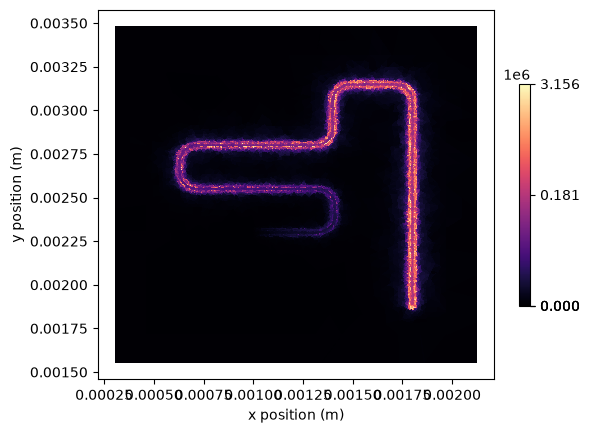

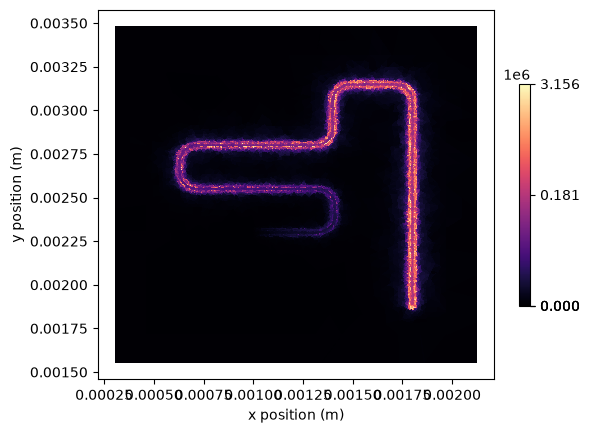

In [ ]:
leSlice.plot(E_total, 'magma', True)
# cambiar escala del eje color a logaritmica


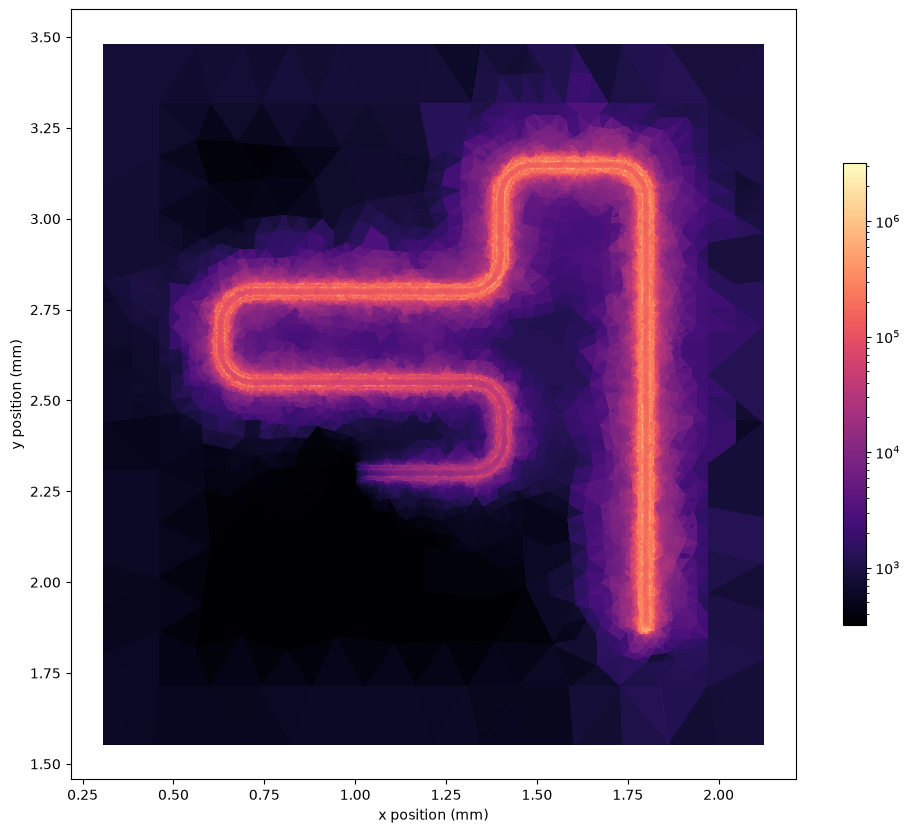

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- datos crudos de la rebanada (lo mismo que usa PVDVTU_Slice.plot internamente) ---
pts = leSlice.slc.points                          # coords en unidades nativas del mesh
tri = leSlice.slc.faces.reshape((-1, 4))[:, 1:]   # conectividad (VTK guarda [3, i, j, k])

# Coordenadas -> mm.  pts*leSlice._units = metros; *1e3 -> mm  (robusto sea cual sea _units)
x_mm = pts[:, 0] * leSlice._units * 1e3
y_mm = pts[:, 1] * leSlice._units * 1e3

# --- LogNorm exige valores estrictamente positivos ---
E = np.asarray(E_total, dtype=float)
vmax  = E.max()
n_dec = 4                       # rango dinámico en décadas (elige tú)
vmin  = vmax / 10**n_dec
E_c   = np.clip(E, vmin, vmax)  # ceros/negativos numéricos -> piso

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
pcm = ax.tripcolor(x_mm, y_mm, tri, E_c,
                   cmap='magma', norm=LogNorm(vmin=vmin, vmax=vmax))
ax.set_xlabel('x position (mm)')
ax.set_ylabel('y position (mm)')
ax.set_aspect('equal')          # el original no lo fija; conviene para geometría física
fig.colorbar(pcm, ax=ax, shrink=0.6)
plt.show()

### Capacitance


In [12]:
from SQDMetal.PALACE.Capacitance_Simulation import PALACE_Capacitance_Simulation
import contextlib
import sys
from io import StringIO

path2palace = "/Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace"
num_cpus = 1

#Eigenmode Simulation Options
user_defined_options = {
                "mesh_refinement": 0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solver_order": 2,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solns_to_save": 3,                                #number of solutions to save for E-field visualization - ordered by the entries in the computed capacitance matrix
                "solver_tol": 1.0e-8,                              #error residual tolerance for iterative solver
                "solver_maxits": 200,                              #number of solver iterations
                "fillet_resolution":16,                            #number of vertices per quarter turn on a filleted path
                "palace_dir": path2palace, #"PATH/TO/PALACE/BINARY",
                "num_cpus": num_cpus,                                  #number of threads to use in PALACE simulation
                #e.g.: "palace_dir":"/home/prasanna/spack/opt/spack/linux-ubuntu24.04-zen2/gcc-13.2.0/palace-0.12.0-q65qvkwsa5zglixv3rmm424wqsu3mcpv/bin/palace"
                }

#Create the Palace capacitance simulation
cap_sim = PALACE_Capacitance_Simulation(name = 'cirTransmon',                                      #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",                                  #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'                                          
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add metallic elements from layer 1 in design file
cap_sim.add_metallic(1)

#Add ground plane to simulations
cap_sim.add_ground_plane()

#Fine mesh the transmon cross qubit region
cap_sim.fine_mesh_components(['Q1'], min_size=12e-6, max_size=100e-6, taper_dist_min=10e-6, metals_only=False)

#Fine mesh resonator, launch pads and transmission line

# Fine mesh moderado siguiendo el centro de las rutas CPW largas.
cap_sim.fine_mesh_along_path(
    qObjName='meandro_1',
    dist_resolution=10e-6,
    min_size=6e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)
cap_sim.fine_mesh_along_path(
    qObjName='con_charge_line',
    dist_resolution=10e-6, 
    min_size=12e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)


#This will prepare the mesh file and the config file
cap_sim.prepare_simulation()

num_iterations = 6 #Number of adaptive mesh refinement iterations to perform

cap_sim.enable_mesh_refinement(
    num_iterations,              # int  -> MaxIts, cuántas rondas de AMR (esto lo ACTIVA)
    max_DoFs=0,                  # int  -> MaxSize, tope de DoF (0 = sin límite, limitado por RAM)
    tolerance=1e-2,             # float-> Tol, error relativo de convergencia
    Dorfler_marking_fraction=0.7,# float-> UpdateFraction, agresividad del marcado
    save_iterations_data=True,   # guarda output de cada iteración
    save_iterations_mesh=False,  # guarda la malla de cada iteración
    nonconformal=True            # refinamiento no-conforme (default recomendado)
)


In [15]:
capMat = cap_sim.run(stream_output=True)

>> /opt/homebrew/bin/mpirun -n 1 /Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace-arm64.bin cirTransmon.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen
Weak Register   : /gpu/hip/shared
Weak Register   : /gpu/sycl/ref
Weak Register   : /gpu/sycl/shared
Weak Register   : /gpu/sycl/gen
Weak Register   : /gpu/cuda/magma
Weak Register   : /gpu/hip/magma
Weak Register   : /gpu/cuda/magma/det
Weak Register   : /gp

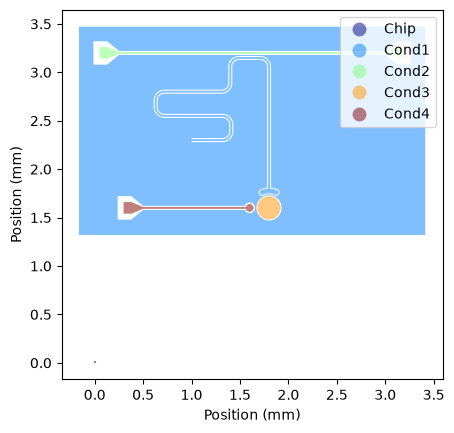

In [16]:
#Display the indices of the conductors to match with capacitance matrix - it will be automatically generated with the output anyway
cap_sim.display_conductor_indices()
plt.show()

In [17]:
capMat

array([[ 3.14369776e-12, -1.22023107e-12, -1.07113126e-13,
        -2.93579304e-13],
       [-1.22023107e-12,  1.24955925e-12, -4.03977477e-19,
        -6.95199425e-19],
       [-1.07113126e-13, -4.03977477e-19,  1.18460262e-13,
        -1.80209596e-15],
       [-2.93579304e-13, -6.95199425e-19, -1.80209596e-15,
         3.09113146e-13]])

In [11]:
sub_design = build_subdesign(
    design,
    keep=['Q1'],
    terminations={('Q1', 'charge_line'): 'open', ('Q1', 'claw_a'): 'open'},
)

Sub-diseno creado. Componentes conservados (1): ['Q1']
Terminaciones agregadas por pines colgantes:
  - term_Q1_claw_a (open) en reemplazo de Q1.claw_a
  - term_Q1_charge_line (open) en reemplazo de Q1.charge_line


In [12]:
gui2 = MetalGUI(sub_design)

In [13]:
from SQDMetal.PALACE.Capacitance_Simulation import PALACE_Capacitance_Simulation
import contextlib
import sys
from io import StringIO

path2palace = "/Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace"
num_cpus = 1

#Eigenmode Simulation Options
user_defined_options = {
                "mesh_refinement": 0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solver_order": 2,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solns_to_save": 3,                                #number of solutions to save for E-field visualization - ordered by the entries in the computed capacitance matrix
                "solver_tol": 1.0e-8,                              #error residual tolerance for iterative solver
                "solver_maxits": 200,                              #number of solver iterations
                "fillet_resolution":16,                            #number of vertices per quarter turn on a filleted path
                "palace_dir": path2palace, #"PATH/TO/PALACE/BINARY",
                "num_cpus": num_cpus,                                  #number of threads to use in PALACE simulation
                #e.g.: "palace_dir":"/home/prasanna/spack/opt/spack/linux-ubuntu24.04-zen2/gcc-13.2.0/palace-0.12.0-q65qvkwsa5zglixv3rmm424wqsu3mcpv/bin/palace"
                }

#Create the Palace capacitance simulation
cap_sim = PALACE_Capacitance_Simulation(name = 'cirTransmon',                                      #name of simulation
                                        metal_design = sub_design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",                                  #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'                                          
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add metallic elements from layer 1 in design file
cap_sim.add_metallic(1)

#Add ground plane to simulations
cap_sim.add_ground_plane()

#Fine mesh the transmon cross qubit region
cap_sim.fine_mesh_components(['Q1'], min_size=12e-6, max_size=100e-6, taper_dist_min=10e-6, metals_only=False)

#Fine mesh resonator, launch pads and transmission line

# Fine mesh moderado siguiendo el centro de las rutas CPW largas.
# cap_sim.fine_mesh_along_path(
#     qObjName='meandro_1',
#     dist_resolution=10e-6,
#     min_size=6e-6, 
#     max_size=150e-6, 
#     taper_dist_min=10e-6
# )
# cap_sim.fine_mesh_along_path(
#     qObjName='con_charge_line',
#     dist_resolution=10e-6, 
#     min_size=12e-6, 
#     max_size=150e-6, 
#     taper_dist_min=10e-6
# )


#This will prepare the mesh file and the config file
cap_sim.prepare_simulation()

num_iterations = 6 #Number of adaptive mesh refinement iterations to perform

cap_sim.enable_mesh_refinement(
    num_iterations,              # int  -> MaxIts, cuántas rondas de AMR (esto lo ACTIVA)
    max_DoFs=0,                  # int  -> MaxSize, tope de DoF (0 = sin límite, limitado por RAM)
    tolerance=1e-2,             # float-> Tol, error relativo de convergencia
    Dorfler_marking_fraction=0.7,# float-> UpdateFraction, agresividad del marcado
    save_iterations_data=True,   # guarda output de cada iteración
    save_iterations_mesh=False,  # guarda la malla de cada iteración
    nonconformal=True            # refinamiento no-conforme (default recomendado)
)


In [14]:
capMat = cap_sim.run(stream_output=True)

>> /opt/homebrew/bin/mpirun -n 1 /Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace-arm64.bin cirTransmon.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen
Weak Register   : /gpu/hip/shared
Weak Register   : /gpu/sycl/ref
Weak Register   : /gpu/sycl/shared
Weak Register   : /gpu/sycl/gen
Weak Register   : /gpu/cuda/magma
Weak Register   : /gpu/hip/magma
Weak Register   : /gpu/cuda/magma/det
Weak Register   : /gp

In [15]:
capMat

array([[ 1.76469003e-12, -1.02256321e-13, -5.79456661e-14,
        -4.26875564e-14],
       [-1.02256321e-13,  1.18674836e-13, -5.16675579e-15,
        -1.70791927e-15],
       [-5.79456661e-14, -5.16675579e-15,  6.58249407e-14,
        -1.23421832e-16],
       [-4.26875564e-14, -1.70791927e-15, -1.23421832e-16,
         4.64259599e-14]])

In [18]:
data = cap_sim.retrieve_data()

array([[ 1.76469003e-12, -1.02256321e-13, -5.79456661e-14,
        -4.26875564e-14],
       [-1.02256321e-13,  1.18674836e-13, -5.16675579e-15,
        -1.70791927e-15],
       [-5.79456661e-14, -5.16675579e-15,  6.58249407e-14,
        -1.23421832e-16],
       [-4.26875564e-14, -1.70791927e-15, -1.23421832e-16,
         4.64259599e-14]])

In [27]:
capMat[0, 1]*(-1e15)

102.2563211495

In [25]:
capMat[1, 2]*(-1e15)

5.166755794194

In [30]:
cap_sim._label_cap_terminals()

['ground_main_plane', 'pads_Q1', 'claw_a_Q1', 'charge_line_Q1']

In [28]:
cap_sim.get_capacitance_matrix(units='fF')

,ground_main_plane,pads_Q1,claw_a_Q1,charge_line_Q1
ground_main_plane,1764.690027,-102.256321,-57.945666,-42.687556
pads_Q1,-102.256321,118.674836,-5.166756,-1.707919
claw_a_Q1,-57.945666,-5.166756,65.824941,-0.123422
charge_line_Q1,-42.687556,-1.707919,-0.123422,46.425960


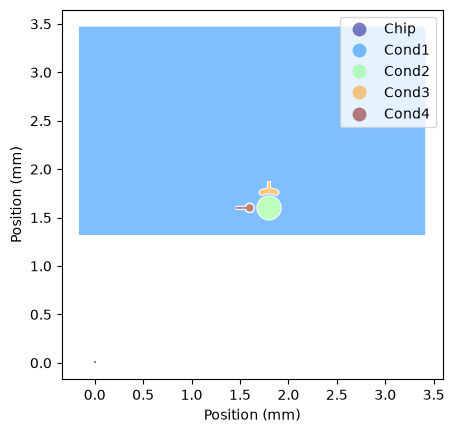

In [ ]:
#Display the indices of the conductors to match with capacitance matrix - it will be automatically generated with the output anyway
%matplotlib inline
cap_sim.display_conductor_indices()
plt.show()


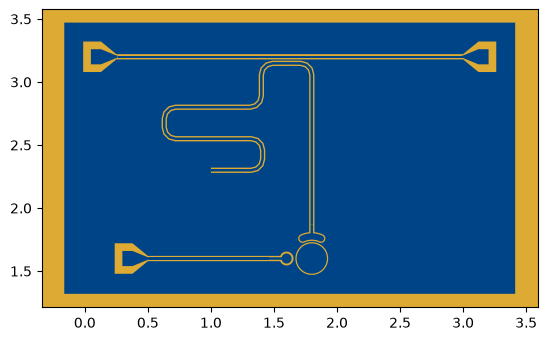

: 

In [ ]:
QUtilities.plot_all_components(design)
plt.show()